###   1. Loading Dataset

In [1]:
import torch
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True)
])

toImage = T.Compose([
    T.ToImage()
])


train_and_valid_data = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=toTensor
)

test_data = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=toTensor
)

In [2]:
print(len(train_and_valid_data))
print(len(test_data))

60000
10000


In [3]:
X, y = train_and_valid_data[0]

print(X.shape)
print(X.dtype)
print(y)

torch.Size([1, 28, 28])
torch.float32
9


##### Checking value range

In [4]:
print(X.min(), X.max())

tensor(0.) tensor(1.)


### 2. Visualize Samples

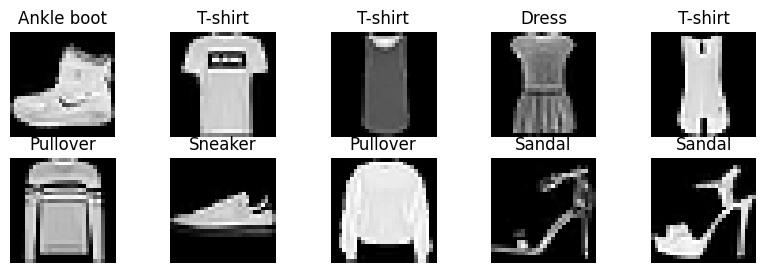

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 3))

labels_map = {
    0: "T-shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}
for i in range(2):
    for j in range(5):
        idx = i * 5 + j
        img, label = train_and_valid_data[idx]
        axes[i, j].imshow(img.squeeze(), cmap='gray')
        axes[i, j].set_title(labels_map[label])
        axes[i, j].axis('off')

plt.show()

### DataLoader

In [6]:
from torch.utils.data import DataLoader

train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [0.9, 0.1])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [7]:
X, y = next(iter(train_loader))
print(X.shape)
print(X.min(), X.max())

torch.Size([32, 1, 28, 28])
tensor(0.) tensor(1.)


### Phase 2

#### First Working Model

In [11]:
import torch.nn as nn

class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_stack = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.fc_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    
    def forward(self, X):
        X = self.conv_stack(X)
        X = self.fc_stack(X)
        return X

In [12]:
model = CNNClassifier()

In [13]:
X, y = next(iter(train_loader))
y_pred = model(X)

print(X.shape)
print(y_pred.shape)

torch.Size([32, 1, 28, 28])
torch.Size([32, 10])


#### Train the CNN

In [14]:
import torchmetrics

learning_rate = 0.01
n_epochs = 10

criterion = nn.CrossEntropyLoss()
optimzer = torch.optim.SGD(model.parameters(), lr=learning_rate)
metric = torchmetrics.Accuracy(task='multiclass', num_classes=10)

In [15]:
def train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
    history = {'loss': [], 'train_acc': [], 'valid_acc': []}

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        metric.reset()

        for X_batch, y_batch in train_loader:
            y_pred = model(X_batch)

            loss = criterion(y_pred, y_batch)

            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

            total_loss += loss.item()
            metric.update(y_pred, y_batch)

        avg_loss = total_loss / len(train_loader)
        train_acc = metric.compute().item()

        model.eval()
        metric.reset()

        with torch.inference_mode():
            for X_batch, y_batch in valid_loader:
                y_pred = model(X_batch)
                metric.update(y_pred, y_batch)

        valid_acc = metric.compute().item()

        history['loss'].append(avg_loss)
        history['train_acc'].append(train_acc)
        history['valid_acc'].append(valid_acc)

        print(f"Epoch {epoch+1}/{n_epochs} | Loss: {avg_loss:.3f} | Train Acc: {train_acc:.3f} | Valid Acc: {valid_acc:.3f}")

    return history

In [ ]:
history = 